In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mahdimashayekhi/fake-news-detection-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'fake-news-detection-dataset' dataset.
Path to dataset files: /kaggle/input/fake-news-detection-dataset


#Data Visulisation and some feature Extrextion

In [ ]:
import os
import pandas as pd
print(os.listdir(path))
df = pd.read_csv(path + "/fake_news_dataset.csv")
df.head(2)

['fake_news_dataset.csv']


,title,text,date,source,author,category,label
0,Foreign Democrat final.,more tax development both store agreement lawy...,2023-03-10,NY Times,Paula George,Politics,real
1,To offer down resource great point.,probably guess western behind likely next inve...,2022-05-25,Fox News,Joseph Hill,Politics,fake


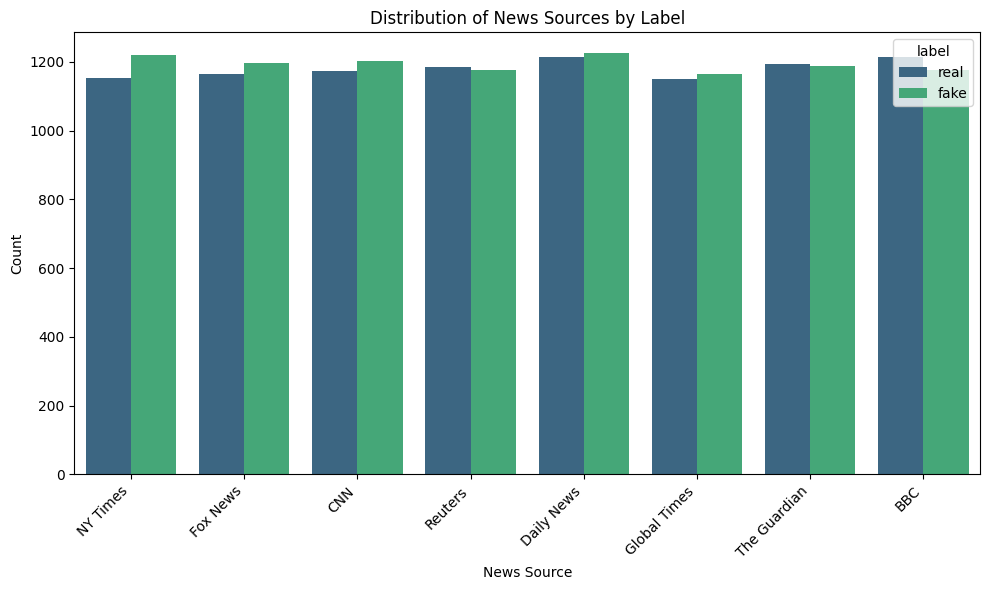

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='source', hue='label', palette='viridis')
plt.title('Distribution of News Sources by Label')
plt.xlabel('News Source')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

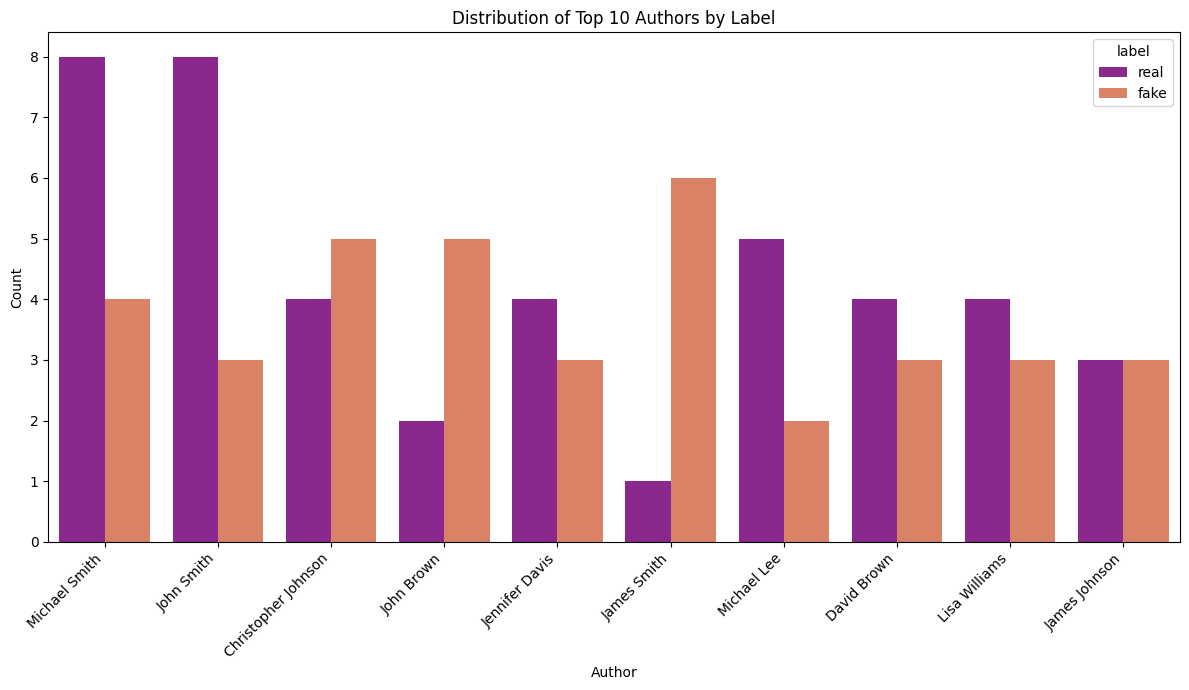

In [ ]:
top_authors = df['author'].value_counts().nlargest(10).index
df_top_authors = df[df['author'].isin(top_authors)]

plt.figure(figsize=(12, 7))
sns.countplot(data=df_top_authors, x='author', hue='label', palette='plasma', order=top_authors)
plt.title('Distribution of Top 10 Authors by Label')
plt.xlabel('Author')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

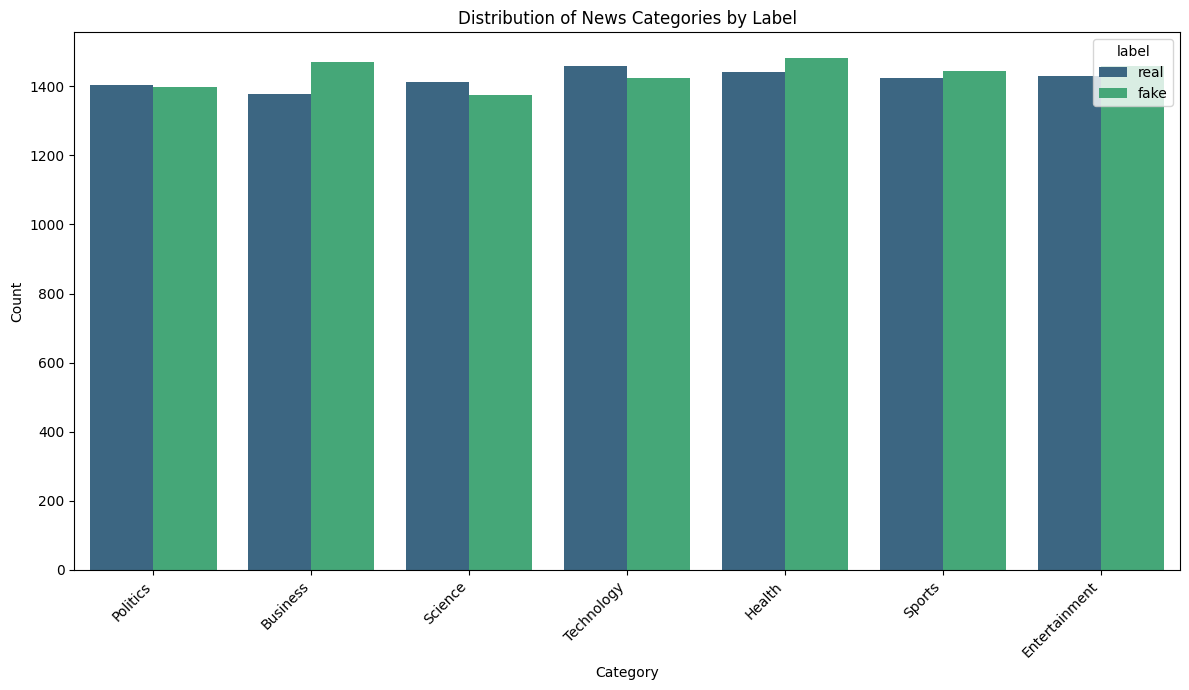

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.countplot(data=df, x='category', hue='label', palette='viridis')
plt.title('Distribution of News Categories by Label')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
df['date'] = pd.to_datetime(df['date'])
max_date = df['date'].max()
threshold_date = max_date - pd.DateOffset(months=6)
df['news_category'] = df['date'].apply(lambda x: 'latest news' if x > threshold_date else 'old news')

In [ ]:
df.head(2)

,title,text,date,source,author,category,label,news_category
0,Foreign Democrat final.,more tax development both store agreement lawy...,2023-03-10,NY Times,Paula George,Politics,real,old news
1,To offer down resource great point.,probably guess western behind likely next inve...,2022-05-25,Fox News,Joseph Hill,Politics,fake,old news


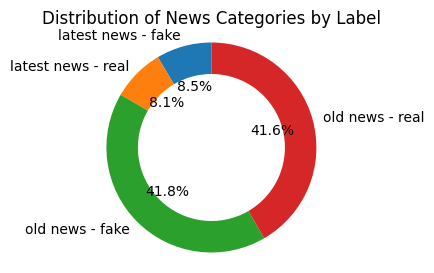

In [ ]:
category_label_counts = df.groupby(['news_category', 'label']).size().unstack(fill_value=0)
pie_data = category_label_counts.stack()
pie_labels = [f'{cat} - {lbl}' for cat, lbl in pie_data.index]
pie_sizes = pie_data.values
plt.figure(figsize=(5, 3))
plt.pie(pie_sizes, labels=pie_labels, autopct='%1.1f%%', startangle=90, wedgeprops=dict(width=0.3))
plt.title('Distribution of News Categories by Label')
plt.axis('equal')
plt.show()

#Data Preprocessing


In [ ]:
df.head()

,title,text,date,source,author,category,label,news_category
0,Foreign Democrat final.,more tax development both store agreement lawy...,2023-03-10,NY Times,Paula George,Politics,real,old news
1,To offer down resource great point.,probably guess western behind likely next inve...,2022-05-25,Fox News,Joseph Hill,Politics,fake,old news
2,Himself church myself carry.,them identify forward present success risk sev...,2022-09-01,CNN,Julia Robinson,Business,fake,old news
3,You unit its should.,phone which item yard Republican safe where po...,2023-02-07,Reuters,Mr. David Foster DDS,Science,fake,old news
4,Billion believe employee summer how.,wonder myself fact difficult course forget exa...,2023-04-03,CNN,Austin Walker,Technology,fake,old news


In [ ]:
df['all_text'] = df['title'] + ' ' + df['text'] + ' ' + df['author'] + ' ' + df['source'] + ' ' + df['category'] + ' ' + df['news_category']
df.head()

,title,text,date,source,author,category,label,news_category,all_text
0,Foreign Democrat final.,more tax development both store agreement lawy...,2023-03-10,NY Times,Paula George,Politics,real,old news,Foreign Democrat final. more tax development b...
1,To offer down resource great point.,probably guess western behind likely next inve...,2022-05-25,Fox News,Joseph Hill,Politics,fake,old news,To offer down resource great point. probably g...
2,Himself church myself carry.,them identify forward present success risk sev...,2022-09-01,CNN,Julia Robinson,Business,fake,old news,Himself church myself carry. them identify for...
3,You unit its should.,phone which item yard Republican safe where po...,2023-02-07,Reuters,Mr. David Foster DDS,Science,fake,old news,You unit its should. phone which item yard Rep...
4,Billion believe employee summer how.,wonder myself fact difficult course forget exa...,2023-04-03,CNN,Austin Walker,Technology,fake,old news,Billion believe employee summer how. wonder my...


In [ ]:
df['label'] = df['label'].map({'real':1, 'fake':0})
df.head()

,title,text,date,source,author,category,label,news_category,all_text
0,Foreign Democrat final.,more tax development both store agreement lawy...,2023-03-10,NY Times,Paula George,Politics,1,old news,Foreign Democrat final. more tax development b...
1,To offer down resource great point.,probably guess western behind likely next inve...,2022-05-25,Fox News,Joseph Hill,Politics,0,old news,To offer down resource great point. probably g...
2,Himself church myself carry.,them identify forward present success risk sev...,2022-09-01,CNN,Julia Robinson,Business,0,old news,Himself church myself carry. them identify for...
3,You unit its should.,phone which item yard Republican safe where po...,2023-02-07,Reuters,Mr. David Foster DDS,Science,0,old news,You unit its should. phone which item yard Rep...
4,Billion believe employee summer how.,wonder myself fact difficult course forget exa...,2023-04-03,CNN,Austin Walker,Technology,0,old news,Billion believe employee summer how. wonder my...


In [ ]:

import string
from sklearn.preprocessing import LabelEncoder
import warnings
import nltk
nltk.download('stopwords') # Download NLTK stopwords
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.metrics.pairwise import cosine_similarity
stop=set(stopwords.words('english'))
warnings.filterwarnings("ignore")
from sklearn.feature_extraction.text import CountVectorizer
import string

stop = set(stopwords.words('english'))

def remove_num(txt):
    new = ''
    for i in str(txt): # Added str() to handle potential non-string data
        if not i.isdigit():
            new = new + i
    return new

def remove_pun(txt):
    # Fixed: The first two arguments should be empty strings, not ' '
    return str(txt).translate(str.maketrans('', '', string.punctuation))

def remove_stopwords(txt):
    word = str(txt).split()
    text = []
    for i in word:
        if i not in stop:
            text.append(i)
    # FIX: You were returning 'txt' (original). You must return " ".join(text)
    return " ".join(text)

def remove_emoji(txt):
    e = ""
    for i in str(txt):
        if i.isascii():
            e = e + i
    return e

def to_lower(txt):
    return str(txt).lower()

import pandas as pd
!pip install langdetect
!pip install deep_translator
from langdetect import detect
from deep_translator import GoogleTranslator

def translate_if_hindi(text):
    """
    Detects if the text is Hindi. If yes, translates to English.
    Otherwise, returns the original text.
    """
    # 1. Handle empty cells or missing data (NaN)
    if pd.isna(text) or not str(text).strip():
        return text

    # Convert to string just in case
    text = str(text)

    try:
        # 2. Detect the language
        # 'hi' is the standard language code for Hindi
        lang = detect(text)

        # 3. Translate if it is Hindi
        if lang == 'hi':
            # Translate from Hindi to English
            translated = GoogleTranslator(source='hi', target='en').translate(text)
            return translated
        else:
            # If it's English, Spanish, etc., leave it alone
            return text

    except Exception as e:
        # This catches errors (e.g., if the text is just numbers or emojis)
        # It will just return the original text without crashing
        return text

def master_clean(txt):
    # If the input is Null/NaN, return an empty string to avoid crashes
    if not isinstance(txt, str) and not isinstance(txt, (int, float)):
        return ""

    txt = to_lower(txt)
    txt = remove_emoji(txt)
    txt = remove_pun(txt)
    txt = remove_num(txt)
    txt = remove_stopwords(txt)
    txt = translate_if_hindi(txt)
    return txt


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
df['all_text'] = df['all_text'].apply(master_clean)

In [ ]:
df.head(2)

,title,text,date,source,author,category,label,news_category,all_text,char_count,word_count,avg_word_len
0,Foreign Democrat final.,more tax development both store agreement lawy...,2023-03-10,NY Times,Paula George,Politics,1,old news,foreign democrat final tax development store a...,1434,216,6.608295
1,To offer down resource great point.,probably guess western behind likely next inve...,2022-05-25,Fox News,Joseph Hill,Politics,0,old news,offer resource great point probably guess west...,1588,238,6.644351


In [ ]:
import numpy as np

# 1. Feature Engineering: Structural Meta-data
df['char_count'] = df['text'].apply(len)
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))
df['avg_word_len'] = df['char_count'] / (df['word_count'] + 1)

# Normalize these features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
meta_features = scaler.fit_transform(df[['char_count', 'word_count', 'avg_word_len']])

print("Meta-features created and normalized.")

Meta-features created and normalized.


In [ ]:
from tensorflow.keras.layers import Input, Concatenate, Dense, Embedding, GlobalAveragePooling1D
from tensorflow.keras.models import Model

# 2. Multi-Input Model (Text + Meta-features)
text_input = Input(shape=(MAX_LEN,), name='text_input')
embedding = Embedding(input_dim=VOCAB_SIZE, output_dim=16)(text_input)
pooling = GlobalAveragePooling1D()(embedding)

meta_input = Input(shape=(3,), name='meta_input')

merged = Concatenate()([pooling, meta_input])
x = Dense(16, activation='relu')(merged)
x = Dropout(0.2)(x)
output = Dense(1, activation='sigmoid')(x)

model_v2 = Model(inputs=[text_input, meta_input], outputs=output)
model_v2.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Split data
meta_train, meta_test = train_test_split(meta_features, test_size=0.2, random_state=42)

print("Retraining with structural features...")
history_v2 = model_v2.fit(
    [X_train, meta_train], y_train,
    epochs=20,
    batch_size=32,
    validation_data=([X_test, meta_test], y_test),
    verbose=1
)

Retraining with structural features...
Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.4985 - loss: 0.7028 - val_accuracy: 0.5092 - val_loss: 0.6936
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5027 - loss: 0.6937 - val_accuracy: 0.5048 - val_loss: 0.6934
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5122 - loss: 0.6932 - val_accuracy: 0.5140 - val_loss: 0.6934
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5199 - loss: 0.6922 - val_accuracy: 0.5020 - val_loss: 0.6939
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5319 - loss: 0.6908 - val_accuracy: 0.5008 - val_loss: 0.6936
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5491 - loss: 0.6888 - val_accuracy: 0.5067 - val_loss: 0.6928
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5589 - loss: 0.6852 - val_accuracy: 0.5132 - val_loss: 0.6937
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0

In [ ]:
!pip uninstall -y gradio websockets huggingface_hub
!pip install websockets gradio huggingface_hub --upgrade -q

import sys
# Forcefully clear existing references from memory to ensure new versions are used
for module in list(sys.modules.keys()):
    if any(pkg in module for pkg in ['gradio', 'websockets', 'huggingface_hub']):
        del sys.modules[module]

import gradio as gr
import numpy as np
import pandas as pd
from tensorflow.keras.preprocessing.sequence import pad_sequences

# threshold_date and MAX_LEN are assumed to be defined in previous cells

def predict_news(title, text, date, source, author, category):
    try:
        # 1. Determine news_category based on the input date
        input_dt = pd.to_datetime(date)
        news_cat = 'latest news' if input_dt > threshold_date else 'old news'

        # 2. Combine and Clean using the pipeline defined earlier
        combined_text = f"{title} {text} {author} {source} {category} {news_cat}"
        cleaned_text = master_clean(combined_text)

        # 3. Process for LSTM
        seq = tokenizer.texts_to_sequences([cleaned_text])
        padded = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')

        # 4. Predict
        prediction = float(model.predict(padded, verbose=0)[0][0])

        return {"Real News": prediction, "Fake News": 1.0 - prediction}
    except Exception as e:
        return {"Error": str(e)}

# Interface setup
interface = gr.Interface(
    fn=predict_news,
    inputs=[
        gr.Textbox(label="Title"),
        gr.Textbox(label="Text", lines=5),
        gr.Textbox(label="Date (YYYY-MM-DD)", placeholder="2023-01-01"),
        gr.Textbox(label="Source"),
        gr.Textbox(label="Author"),
        gr.Dropdown(choices=list(df['category'].unique()) if 'df' in globals() else [], label="Category")
    ],
    outputs=gr.Label(num_top_classes=2),
    title="LSTM Fake News Detector",
    description="Provide news details to predict authenticity."
)

interface.launch(share=True, debug=True)

Found existing installation: gradio 6.19.0
Uninstalling gradio-6.19.0:
  Successfully uninstalled gradio-6.19.0
Found existing installation: websockets 16.0
Uninstalling websockets-16.0:
  Successfully uninstalled websockets-16.0
Found existing installation: huggingface_hub 1.21.0
Uninstalling huggingface_hub-1.21.0:
  Successfully uninstalled huggingface_hub-1.21.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
langgraph-sdk 0.4.2 requires websockets<16,>=14, but you have websockets 16.0 which is incompatible.
google-adk 1.29.0 requires starlette<1.0.0,>=0.49.1, but you have starlette 1.3.1 which is incompatible.
google-adk 1.29.0 requires websockets<16.0.0,>=15.0.1, but you have websockets 16.0 which is incompatible.
Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Runni

In [ ]:
df['text'].iloc[200]

'guy especially interest bit why morning baby really nearly must company material order always walk education feeling high somebody include unit fast live make effort voice dark even south less maybe cup bank focus class probably son two page sport worry certain by summer middle tough star hold check hold step measure someone good as mother leave very condition hundred yet force reality six task better interview physical them small tell shake coach than wish page girl time whose keep war now prove machine main fight type dinner night could because him talk accept worry off through beat fish open factor organization interest vote buy ever parent read natural main give keep agency candidate sport child line describe worry tonight agency instead together organization line wind shoulder board fear beat under word child song conference ten necessary school possible despite agreement approach piece catch enter marriage mention commercial evening food yeah number quality parent whole from wis

In [ ]:
df.iloc[200]

,200
title,Book face middle necessary table.
text,guy especially interest bit why morning baby r...
date,2022-07-21 00:00:00
source,BBC
author,Victor Whitaker
category,Entertainment
label,1
news_category,old news
all_text,book face middle necessary table guy especiall...
char_count,1555
